In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import tiktoken
import os

In [2]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256, # use a shorter context length
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [3]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )

    def forward(self, x):
        return self.layers(x)

class MaskedMultiheadAttention(nn.Module):
    def __init__(self, context_length, dim_in, dim_out, n_heads, dropout_rate, qkv_bias=False):
        super().__init__()
        
        self.context_length = context_length
        self.dim_in = dim_in
        self.dim_out = dim_out
        self.n_heads = n_heads

        assert self.dim_out % self.n_heads == 0, "dim_out should be divisible by n_heads"
        
        self.head_dim = self.dim_out // self.n_heads
        self.W_key = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.W_query = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.W_value = nn.Linear(self.dim_in, self.dim_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout_rate)
        self.out_proj = nn.Linear(self.dim_out, self.dim_out)
        self.register_buffer("mask", torch.triu(torch.ones(self.context_length, self.context_length), diagonal=1).bool())

    def forward(self, x):
        batch_size, num_tokens, dim_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(batch_size, num_tokens, self.n_heads, self.head_dim)
        queries = queries.view(batch_size, num_tokens, self.n_heads, self.head_dim)
        values = values.view(batch_size, num_tokens, self.n_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attention_scores = queries @ keys.transpose(2, 3)
        attention_scores.masked_fill_(self.mask[:num_tokens, :num_tokens], -torch.inf)
        attention_weights = torch.softmax(attention_scores / (keys.shape[-1] ** 0.5), dim=-1)
        attention_weights = self.dropout(attention_weights)
        context_vectors = (attention_weights @ values).transpose(1, 2)
        context_vectors = context_vectors.contiguous().view(batch_size, num_tokens, self.dim_out)
        context_vectors = self.out_proj(context_vectors)
        return context_vectors

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attention = MaskedMultiheadAttention(
            context_length = cfg["context_length"],
            dim_in = cfg["emb_dim"],
            dim_out = cfg["emb_dim"],
            dropout_rate = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"],
            n_heads = cfg["n_heads"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attention(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_embedding(in_idx)
        pos_embeds = self.pos_embedding(torch.arange(seq_len, device=in_idx.device))

        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

class GPTDataSetV1(Dataset):
    def __init__(self, text, tokenizer, context_length, stride):
        self.input_ids = []
        self.target_ids = []

        encodings = tokenizer.encode(text)

        for i in range(0, len(encodings) - context_length, stride):
            inputs = encodings[i:i+context_length]
            targets = encodings[i+1:i+context_length+1]
            self.input_ids.append(torch.tensor(inputs))
            self.target_ids.append(torch.tensor(targets))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def total_params(model):
    return sum(p.numel() for p in model.parameters())

def create_data_loader(text, batch_size=8, context_length=6, stride=3, shuffle=True, drop_last=True):
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset = GPTDataSetV1(text, tokenizer, context_length, stride)
    n_cpus = os.cpu_count()
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=n_cpus)


In [4]:
tokenizer = tiktoken.get_encoding("gpt2")

In [5]:
model = GPTModel(GPT_CONFIG_124M)
total_params(model)

162419712

In [6]:
file_path = "the_verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()

In [7]:
train_ratio = 0.9
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [8]:
train_loader = create_data_loader(train_data, batch_size=2, shuffle=True, context_length=GPT_CONFIG_124M["context_length"], drop_last=True)
val_loader = create_data_loader(val_data, batch_size=2, shuffle=True, context_length=GPT_CONFIG_124M["context_length"], drop_last=True)

In [9]:
len(train_loader), len(val_loader)

(821, 56)

In [10]:
def calc_batch_loss(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [11]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_batch_loss(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break

    return total_loss / num_batches

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.983104360815087
Validation loss: 11.017555151666913


In [13]:
def generate_text_sample(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
            logits = logits[:, -1, :]
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.argmax(probs, dim=-1, keepdim=True)
            idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [14]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epoches, eval_freq, eval_iter, start_context, tokenizer):
    train_lossess, val_lossess, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epoches):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_batch_loss(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_lossess.append(train_loss)
                val_lossess.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(model, tokenizer, device, start_context)
    return train_lossess, val_lossess, track_tokens_seen

In [15]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

In [16]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [17]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_embedding.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_sample(model, idx=encoded, max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()

In [18]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
num_epoches = 10
train_losses, val_lossess, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epoches=num_epoches, eval_freq=5, eval_iter=5,
    start_context= "Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.399, Val loss 9.493
Ep 1 (Step 000005): Train loss 7.747, Val loss 7.923
Ep 1 (Step 000010): Train loss 6.673, Val loss 6.903
Ep 1 (Step 000015): Train loss 6.009, Val loss 6.509
Ep 1 (Step 000020): Train loss 6.296, Val loss 6.390
Ep 1 (Step 000025): Train loss 5.627, Val loss 6.260
Ep 1 (Step 000030): Train loss 5.234, Val loss 6.055
Ep 1 (Step 000035): Train loss 5.080, Val loss 6.023
Ep 1 (Step 000040): Train loss 4.775, Val loss 5.949
Ep 1 (Step 000045): Train loss 4.839, Val loss 5.952
Ep 1 (Step 000050): Train loss 4.265, Val loss 5.911
Ep 1 (Step 000055): Train loss 3.998, Val loss 5.869
Ep 1 (Step 000060): Train loss 3.999, Val loss 5.873
Ep 1 (Step 000065): Train loss 4.034, Val loss 5.881
Ep 1 (Step 000070): Train loss 3.706, Val loss 5.839
Ep 1 (Step 000075): Train loss 3.559, Val loss 5.804
Ep 1 (Step 000080): Train loss 3.356, Val loss 5.847
Ep 1 (Step 000085): Train loss 3.069, Val loss 5.814
Ep 1 (Step 000090): Train loss 3.221, Val loss

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_lossess(epoches_seen, tokens_seen, train_lossess, val_lossess):
    fig, ax1 = plt.subplots(figsize=(5,3))
    ax1.plot(epoches_seen, train_lossess, label="Training loss")
    ax1.plot(
        epoches_seen, val_lossess, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epoches")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

In [25]:
epoch_tensor = torch.linspace(0, num_epoches, len(train_losses))

NameError: name 'val_losses' is not defined

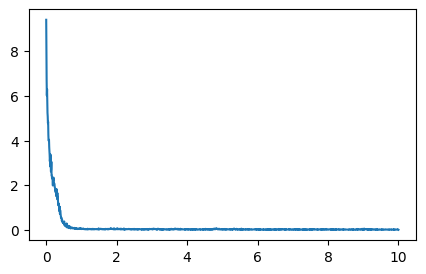

In [29]:
plot_lossess(epoch_tensor, tokens_seen, train_losses, val_lossess)

In [28]:
val_lossess

[9.493009567260742,
 7.923379039764404,
 6.902600860595703,
 6.5086524963378904,
 6.38960542678833,
 6.260477542877197,
 6.055080318450928,
 6.02268762588501,
 5.9486490249633786,
 5.952193737030029,
 5.910755157470703,
 5.868967437744141,
 5.872517490386963,
 5.8808979988098145,
 5.839399719238282,
 5.80400390625,
 5.846919822692871,
 5.813915348052978,
 5.832299423217774,
 5.834763622283935,
 5.957231616973877,
 6.030023288726807,
 6.116136646270752,
 6.164355278015137,
 6.162353420257569,
 6.134705638885498,
 6.125361537933349,
 6.1902436256408695,
 6.27404375076294,
 6.313576030731201,
 6.272554683685303,
 6.312232208251953,
 6.182046890258789,
 6.351481533050537,
 6.292355728149414,
 6.438494300842285,
 6.345375823974609,
 6.416946983337402,
 6.4094014167785645,
 6.3880644798278805,
 6.331152439117432,
 6.4416601181030275,
 6.454773902893066,
 6.377840423583985,
 6.368648529052734,
 6.500348854064941,
 6.503789615631104,
 6.3860067367553714,
 6.57628698348999,
 6.494043445587158,


In [19]:
vocab = sorted(list(set(''.join('abcdefghijklmnopqrstuvwxyz'))) + ['.'])

'z'